# Punto 4 — Modelos para el perímetro de la cintura

## Objetivo

Estudiar cómo se relacionan el género y el peso con el perímetro promedio de la cintura de 507 individuos.

**Variables:**

- `Y = cintura`: perímetro de la cintura, en centímetros.
- `x1 = genero`: indicador binario, 1 para masculino y 0 para femenino.
- `x2 = peso`: peso, en kilogramos.

Se desarrollan los numerales **a–h**: exploración, ajuste de cinco modelos, estimación e interpretación de la dispersión, comparación por AIC, significancia de las variables, modelo final y curvas de regresión por género.

In [14]:
# ============================================================
# 1. Librerías, lectura y preparación de los datos
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.special import digamma, polygamma, gammaln
from scipy.stats import skew
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:.5f}")

# El notebook se ejecuta desde la carpeta del proyecto.
datos = pd.read_excel("Data/cintura.xlsx")
datos = datos.rename(columns={"cintura": "Y", "peso": "x2", "genero": "genero"})
datos["x1"] = (datos["genero"].str.lower() == "male").astype(int)
datos["genero_label"] = datos["x1"].map({0: "Femenino", 1: "Masculino"})

print(f"Dimensiones: {datos.shape[0]} observaciones y {datos.shape[1]} columnas derivadas.")
print("Valores faltantes:")
print(datos[["Y", "x1", "x2"]].isna().sum())
display(datos.head())
print("\nFrecuencia por género:")
display(datos["genero_label"].value_counts().rename_axis("genero").to_frame("n"))

Dimensiones: 507 observaciones y 5 columnas derivadas.
Valores faltantes:
Y     0
x1    0
x2    0
dtype: int64


,Y,x2,genero,x1,genero_label
0,71.50000,65.60000,male,1,Masculino
1,79.00000,71.80000,male,1,Masculino
2,83.20000,80.70000,male,1,Masculino
3,77.80000,72.60000,male,1,Masculino
4,80.00000,78.80000,male,1,Masculino



Frecuencia por género:


,n
genero,
Femenino,260
Masculino,247


# 2. Numeral a: análisis exploratorio

La asimetría se cuantifica con el coeficiente de Fisher (`skewness`). Como regla descriptiva, valores absolutos menores que 0.5 se consideran aproximadamente simétricos, entre 0.5 y 1 moderadamente asimétricos y mayores que 1 fuertemente asimétricos. La decisión final se apoya también en el histograma, el boxplot y los cuantiles.

Resumen de Y (cintura, cm):


,valor
count,507.00000
mean,76.97949
std,11.01269
min,57.90000
25%,68.00000
50%,75.80000
75%,84.50000
max,113.20000



Asimetría de Fisher: 0.5406
Regla 1.5*IQR: [43.25, 109.25] cm
Observaciones atípicas según el boxplot: 2


,Y,x2,genero_label
193,112.10000,92.70000,Masculino
220,113.20000,102.50000,Masculino


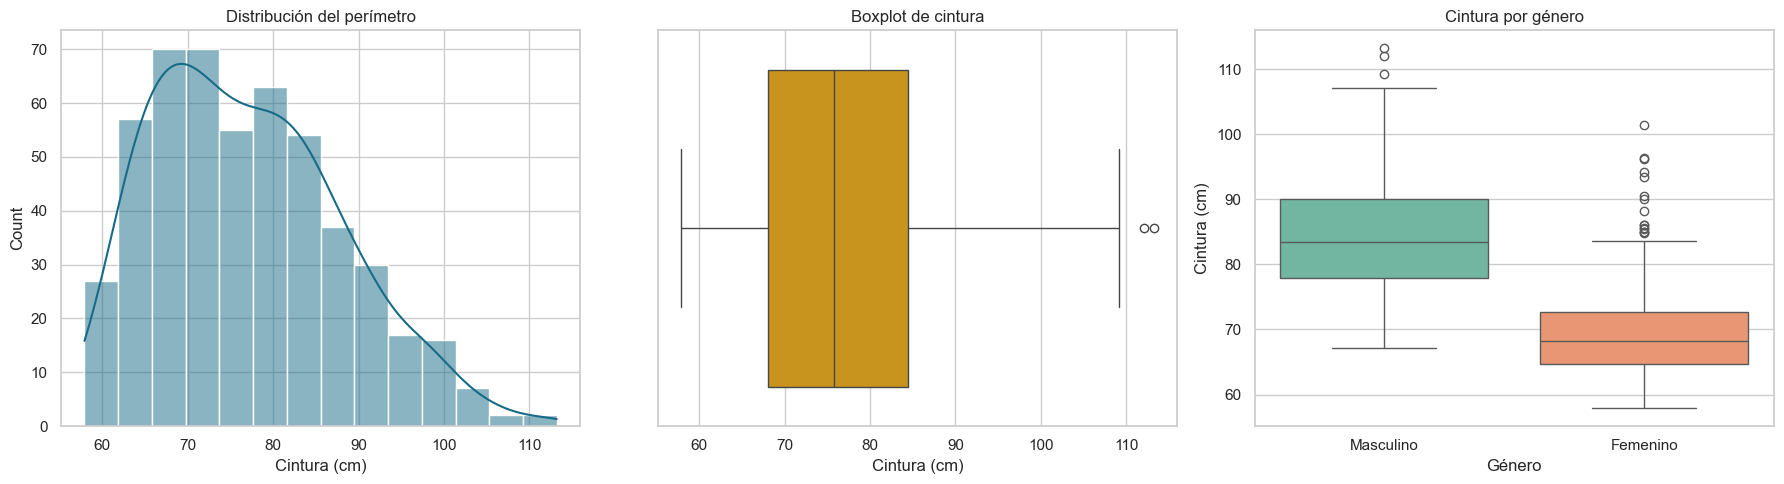

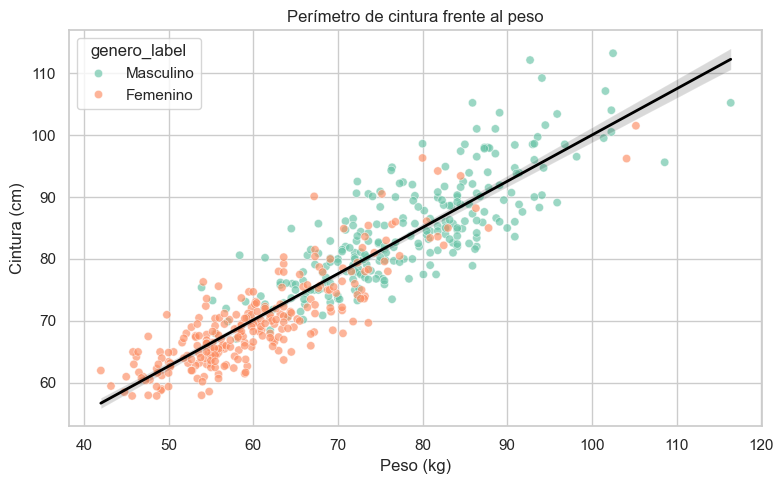


Resumen por género:


,count,mean,std,median,min,max
genero_label,,,,,,
Femenino,260,69.80346,7.58775,68.30000,57.90000,101.50000
Masculino,247,84.53320,8.78224,83.40000,67.10000,113.20000



Interpretación EDA: el signo y magnitud de la asimetría, el número de puntos fuera de los límites del boxplot, la separación entre cajas y la pendiente visual del scatterplot se leen directamente de las salidas anteriores.


In [15]:
# Resumen numérico y detección de atípicos por regla 1.5*IQR
resumen_Y = datos["Y"].describe()
q1, q3 = datos["Y"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = datos.loc[(datos["Y"] < lim_inf) | (datos["Y"] > lim_sup)].copy()

print("Resumen de Y (cintura, cm):")
display(resumen_Y.to_frame("valor"))
print(f"\nAsimetría de Fisher: {skew(datos['Y']):.4f}")
print(f"Regla 1.5*IQR: [{lim_inf:.2f}, {lim_sup:.2f}] cm")
print(f"Observaciones atípicas según el boxplot: {len(atipicos)}")
if len(atipicos):
    display(atipicos[["Y", "x2", "genero_label"]].head(20))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=datos, x="Y", kde=True, color="#176b87", ax=axes[0])
axes[0].set_title("Distribución del perímetro")
axes[0].set_xlabel("Cintura (cm)")
sns.boxplot(data=datos, x="Y", color="#e69f00", ax=axes[1])
axes[1].set_title("Boxplot de cintura")
axes[1].set_xlabel("Cintura (cm)")
sns.boxplot(data=datos, x="genero_label", y="Y", palette="Set2", ax=axes[2])
axes[2].set_title("Cintura por género")
axes[2].set_xlabel("Género")
axes[2].set_ylabel("Cintura (cm)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=datos, x="x2", y="Y", hue="genero_label", alpha=0.65, palette="Set2")
sns.regplot(data=datos, x="x2", y="Y", scatter=False, color="black", line_kws={"linewidth": 2})
plt.title("Perímetro de cintura frente al peso")
plt.xlabel("Peso (kg)")
plt.ylabel("Cintura (cm)")
plt.tight_layout()
plt.show()

print("\nResumen por género:")
display(datos.groupby("genero_label")["Y"].agg(["count", "mean", "std", "median", "min", "max"]))
print("\nInterpretación EDA: el signo y magnitud de la asimetría, el número de puntos fuera de los límites del boxplot, la separación entre cajas y la pendiente visual del scatterplot se leen directamente de las salidas anteriores.")

# 3. Numeral b: ajuste de los cinco modelos

Usamos la matriz `X = (1, x1, x2)`. En la expresión del enunciado, el segundo coeficiente de pendiente se denota correctamente por `beta2`, pues `beta1` corresponde al género y `beta2` al peso.

- **Modelo 1:** Normal, enlace identidad.
- **Modelo 2:** Gamma, enlace inverso.
- **Modelo 3:** Gamma, enlace logarítmico.
- **Modelo 4:** Normal Inversa, enlace inverso cuadrado.
- **Modelo 5:** Normal Inversa, enlace logarítmico.

In [16]:
# ============================================================
# Ajuste de los cinco GLM
# ============================================================
X = sm.add_constant(datos[["x1", "x2"]], has_constant="add")
y = datos["Y"].to_numpy()

modelos = {
    "Modelo 1 - Normal identidad": sm.GLM(y, X, family=sm.families.Gaussian(sm.families.links.identity())).fit(),
    "Modelo 2 - Gamma inverso": sm.GLM(y, X, family=sm.families.Gamma(sm.families.links.inverse_power())).fit(),
    "Modelo 3 - Gamma log": sm.GLM(y, X, family=sm.families.Gamma(sm.families.links.log())).fit(),
    "Modelo 4 - Normal Inversa inverso-cuadrado": sm.GLM(y, X, family=sm.families.InverseGaussian(sm.families.links.inverse_squared())).fit(),
    "Modelo 5 - Normal Inversa log": sm.GLM(y, X, family=sm.families.InverseGaussian(sm.families.links.log())).fit(),
}

coeficientes = pd.DataFrame({nombre: ajuste.params for nombre, ajuste in modelos.items()}).T
coeficientes.columns = ["beta0", "beta1_genero", "beta2_peso"]
print("Coeficientes estimados:")
display(coeficientes)

for nombre, ajuste in modelos.items():
    print(f"\n{nombre}")
    print(ajuste.summary().tables[1])

# Medias ajustadas para cada observación; se usarán en las estimaciones de phi.
medias = {nombre: ajuste.fittedvalues.to_numpy() for nombre, ajuste in modelos.items()}
print("\nTodos los modelos convergieron y producen medias ajustadas positivas:", all(np.all(valor > 0) for valor in medias.values()))

Coeficientes estimados:


,beta0,beta1_genero,beta2_peso
Modelo 1 - Normal identidad,28.92395,2.89489,0.67458
Modelo 2 - Gamma inverso,0.02073,-0.00064,-0.00010
Modelo 3 - Gamma log,3.72592,0.04276,0.00851
Modelo 4 - Normal Inversa inverso-cuadrado,0.00036,-0.00002,-0.00000
Modelo 5 - Normal Inversa log,3.72257,0.04306,0.00856



Modelo 1 - Normal identidad
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.9239      1.262     22.912      0.000      26.450      31.398
x1             2.8949      0.541      5.347      0.000       1.834       3.956
x2             0.6746      0.020     33.238      0.000       0.635       0.714

Modelo 2 - Gamma inverso
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0207      0.000    102.153      0.000       0.020       0.021
x1            -0.0006   8.95e-05     -7.130      0.000      -0.001      -0.000
x2            -0.0001   3.15e-06    -33.107      0.000      -0.000   -9.81e-05

Modelo 3 - Gamma log
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

# 4. Numerales c y d: estimación de `phi` y método de Newton

Para los modelos Gamma, si `k = 1/phi` es el parámetro de forma, la ecuación de score perfilada es

$$g(k)=n\{\log(k)+1-\psi(k)\}+\sum_i\left[\log(Y_i)-\log(\hat\mu_i)-Y_i/\hat\mu_i\right]=0.$$

Se resuelve con Newton, usando

$$k_{nuevo}=k-\frac{g(k)}{g'(k)},\qquad g'(k)=n\{1/k-\psi_1(k)\},$$

y luego `phi = 1/k`. Para los modelos Normal Inversa, la estimación de máxima verosimilitud con medias ajustadas es

$$\hat\phi=\frac{1}{n}\sum_i\frac{(Y_i-\hat\mu_i)^2}{\hat\mu_i^3}.$$

También se muestra la versión de Pearson con `n-p` grados de libertad, útil como estimador de dispersión GLM.

In [17]:
# ============================================================
# Dispersiones, Newton y comparación con gamma.shape
# ============================================================
n = len(y)
p = X.shape[1]

def gamma_score(k, y_obs, mu):
    return n * (np.log(k) + 1 - digamma(k)) + np.sum(np.log(y_obs) - np.log(mu) - y_obs / mu)

def gamma_score_derivative(k):
    return n * (1 / k - polygamma(1, k))

def gamma_shape_newton(y_obs, mu, initial=10.0, tolerance=1e-12, maxiter=100):
    k = float(initial)
    for iteration in range(maxiter):
        step = gamma_score(k, y_obs, mu) / gamma_score_derivative(k)
        k_new = k - step
        if k_new <= 0 or not np.isfinite(k_new):
            k_new = k / 2
        if abs(k_new - k) < tolerance * max(1, abs(k)):
            return k_new, iteration + 1
        k = k_new
    raise RuntimeError("Newton no convergió para el parámetro de forma Gamma")

def gamma_phi_newton(y_obs, mu):
    # Un valor inicial robusto se obtiene mediante Pearson.
    initial_phi = np.sum(((y_obs - mu) ** 2) / mu**2) / (n - p)
    initial_k = max(1e-8, 1 / initial_phi)
    k, iterations = gamma_shape_newton(y_obs, mu, initial=initial_k)
    return 1 / k, k, iterations

def inverse_gaussian_phi(y_obs, mu):
    return np.mean((y_obs - mu) ** 2 / mu**3)

def inverse_gaussian_phi_pearson(y_obs, mu):
    return np.sum((y_obs - mu) ** 2 / mu**3) / (n - p)

phi_gamma = {}
shape_gamma = {}
newton_iter = {}
for nombre in ["Modelo 2 - Gamma inverso", "Modelo 3 - Gamma log"]:
    phi_gamma[nombre], shape_gamma[nombre], newton_iter[nombre] = gamma_phi_newton(y, medias[nombre])

phi_mle = {
    "Modelo 4 - Normal Inversa inverso-cuadrado": inverse_gaussian_phi(y, medias["Modelo 4 - Normal Inversa inverso-cuadrado"]),
    "Modelo 5 - Normal Inversa log": inverse_gaussian_phi(y, medias["Modelo 5 - Normal Inversa log"]),
}
phi_pearson = {
    nombre: inverse_gaussian_phi_pearson(y, medias[nombre])
    for nombre in phi_mle
}

dispersion = pd.DataFrame({
    "phi_MLE_o_Newton": {**phi_gamma, **phi_mle},
    "phi_Pearson_n-p": {nombre: modelos[nombre].pearson_chi2 / (n - p) for nombre in modelos},
    "shape_Gamma": {nombre: shape_gamma.get(nombre, np.nan) for nombre in modelos},
    "iteraciones_Newton": {nombre: newton_iter.get(nombre, np.nan) for nombre in modelos},
})
print("Estimaciones de dispersión:")
display(dispersion)

# gamma.shape de R estima el mismo parámetro de forma k; esta comparación
# reproduce su ecuación de score a partir de las medias ajustadas.
print("\nComparación con gamma.shape de R (k = 1/phi):")
for nombre in ["Modelo 2 - Gamma inverso", "Modelo 3 - Gamma log"]:
    print(f"{nombre}: k = {shape_gamma[nombre]:.8f}; phi = {phi_gamma[nombre]:.8f}")
print("Interpretación: phi controla la variabilidad. En Gamma, k=1/phi; valores grandes de k equivalen a menor dispersión relativa.")

Estimaciones de dispersión:


,phi_MLE_o_Newton,phi_Pearson_n-p,shape_Gamma,iteraciones_Newton
Modelo 2 - Gamma inverso,0.00346,0.00355,288.66968,4.00000
Modelo 3 - Gamma log,0.00327,0.00335,305.87541,4.00000
Modelo 4 - Normal Inversa inverso-cuadrado,0.00005,0.00005,NaN,NaN
Modelo 5 - Normal Inversa log,0.00004,0.00004,NaN,NaN
Modelo 1 - Normal identidad,NaN,21.06287,NaN,NaN



Comparación con gamma.shape de R (k = 1/phi):
Modelo 2 - Gamma inverso: k = 288.66967602; phi = 0.00346417
Modelo 3 - Gamma log: k = 305.87541317; phi = 0.00326930
Interpretación: phi controla la variabilidad. En Gamma, k=1/phi; valores grandes de k equivalen a menor dispersión relativa.


# 5. Numerales e, f y g: AIC, significancia y modelo elegido

Para comparar familias distintas calculamos el log-verosimilitud con la `phi` estimada para cada familia y usamos `AIC = -2 logLik + 2k`, con `k=4` parámetros: tres coeficientes de regresión y una dispersión. Después se evalúan los valores-p de género y peso en el modelo con menor AIC.

In [18]:
# ============================================================
# AIC comparable entre las cinco familias
# ============================================================
phi_modelo = {
    "Modelo 1 - Normal identidad": np.sum((y - medias["Modelo 1 - Normal identidad"]) ** 2) / n,
    **phi_gamma,
    **phi_mle,
}

def loglik_normal(y_obs, mu, phi):
    return -0.5 * np.sum(np.log(2 * np.pi * phi) + (y_obs - mu) ** 2 / phi)

def loglik_gamma(y_obs, mu, phi):
    shape = 1 / phi
    return np.sum(shape * np.log(shape) - gammaln(shape) + (shape - 1) * np.log(y_obs) - shape * np.log(mu) - shape * y_obs / mu)

def loglik_inverse_gaussian(y_obs, mu, phi):
    return -0.5 * np.sum(np.log(2 * np.pi * phi) + 3 * np.log(y_obs) + (y_obs - mu) ** 2 / (phi * mu**2 * y_obs))

loglik = {}
for nombre in modelos:
    if nombre.startswith("Modelo 1"):
        loglik[nombre] = loglik_normal(y, medias[nombre], phi_modelo[nombre])
    elif nombre.startswith("Modelo 2") or nombre.startswith("Modelo 3"):
        loglik[nombre] = loglik_gamma(y, medias[nombre], phi_modelo[nombre])
    else:
        loglik[nombre] = loglik_inverse_gaussian(y, medias[nombre], phi_modelo[nombre])

aic = pd.DataFrame({
    "logLik": pd.Series(loglik),
    "phi": pd.Series(phi_modelo),
})
aic["AIC"] = -2 * aic["logLik"] + 2 * (p + 1)
aic = aic.sort_values("AIC")
print("Comparación de modelos:")
display(aic)
modelo_elegido = aic.index[0]
ajuste_final = modelos[modelo_elegido]
print(f"\nModelo elegido por AIC: {modelo_elegido}")
print(f"Diferencia AIC frente al segundo: {aic.iloc[1]['AIC'] - aic.iloc[0]['AIC']:.4f}")

print("\nValores-p del modelo elegido:")
inferencia = pd.DataFrame({
    "estimacion": ajuste_final.params,
    "error_std": ajuste_final.bse,
    "estadistico": ajuste_final.tvalues,
    "valor_p": ajuste_final.pvalues,
})
inferencia.index = ["Intercepto", "Genero (x1)", "Peso (x2)"]
display(inferencia)

alpha = 0.05
for variable, pvalor in [("género", ajuste_final.pvalues["x1"]), ("peso", ajuste_final.pvalues["x2"])]:
    decision = "sí afecta significativamente" if pvalor < alpha else "no muestra un efecto significativo"
    print(f"A nivel {alpha:.0%}, {variable} {decision} a la media (p = {pvalor:.5g}).")

print("\nModelo ajustado en escala del predictor lineal:")
print(f"eta = {ajuste_final.params['const']:.6f} + ({ajuste_final.params['x1']:.6f}) x1 + ({ajuste_final.params['x2']:.6f}) x2")
print("La transformación inversa del enlace da la media ajustada: mu_hat = g^(-1)(eta).")

Comparación de modelos:


,logLik,phi,AIC
Modelo 5 - Normal Inversa log,-1458.97135,0.00004,2925.94270
Modelo 3 - Gamma log,-1465.98573,0.00327,2939.97147
Modelo 2 - Gamma inverso,-1480.67854,0.00346,2969.35708
Modelo 1 - Normal identidad,-1490.44166,20.93824,2988.88332
Modelo 4 - Normal Inversa inverso-cuadrado,-1498.86546,0.00005,3005.73091



Modelo elegido por AIC: Modelo 5 - Normal Inversa log
Diferencia AIC frente al segundo: 14.0288

Valores-p del modelo elegido:


,estimacion,error_std,estadistico,valor_p
Intercepto,3.72257,0.01598,232.98734,0.00000
Genero (x1),0.04306,0.00683,6.30700,0.00000
Peso (x2),0.00856,0.00026,32.79819,0.00000


A nivel 5%, género sí afecta significativamente a la media (p = 2.845e-10).
A nivel 5%, peso sí afecta significativamente a la media (p = 6.2478e-236).

Modelo ajustado en escala del predictor lineal:
eta = 3.722568 + (0.043057) x1 + (0.008558) x2
La transformación inversa del enlace da la media ajustada: mu_hat = g^(-1)(eta).


In [19]:
# Interpretación contextual de los parámetros del modelo elegido
b0, b1, b2 = ajuste_final.params[["const", "x1", "x2"]]
print("\nInterpretación contextual:")
print(f"- beta0 = {b0:.5f}: valor del predictor lineal cuando x1=0 y x2=0; es el intercepto en la escala del enlace.")
print(f"- beta1 = {b1:.5f}: cambio del predictor lineal al pasar de femenino a masculino manteniendo fijo el peso.")
print(f"- beta2 = {b2:.5f}: cambio del predictor lineal por cada kg adicional, manteniendo fijo el género.")
if "Modelo 1" in modelo_elegido:
    print("Como el enlace es identidad, los cambios anteriores se interpretan directamente en centímetros de cintura promedio.")
elif "Gamma log" in modelo_elegido or "Normal Inversa log" in modelo_elegido:
    print("Como el enlace es log, un aumento de una unidad en un predictor multiplica la media por exp(beta); para el peso, el factor por kg es exp(beta2).")
else:
    print("Como el enlace es inverso, los coeficientes actúan sobre 1/mu; la media se obtiene como mu=1/eta.")


Interpretación contextual:
- beta0 = 3.72257: valor del predictor lineal cuando x1=0 y x2=0; es el intercepto en la escala del enlace.
- beta1 = 0.04306: cambio del predictor lineal al pasar de femenino a masculino manteniendo fijo el peso.
- beta2 = 0.00856: cambio del predictor lineal por cada kg adicional, manteniendo fijo el género.
Como el enlace es log, un aumento de una unidad en un predictor multiplica la media por exp(beta); para el peso, el factor por kg es exp(beta2).


# 6. Numeral h: curvas ajustadas por género

Se mantienen los puntos observados y se superpone la media condicional estimada por el modelo seleccionado. La curva se calcula con `x1=0` para femenino y `x1=1` para masculino, mientras el peso recorre el rango observado.

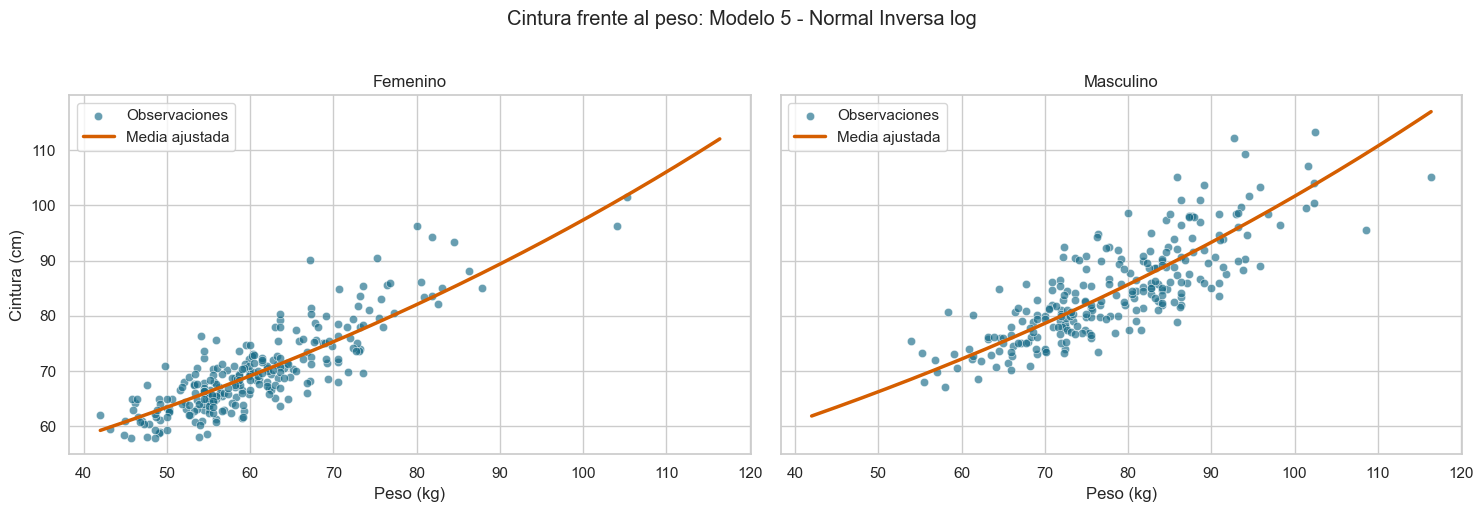

Comentario: las curvas muestran el cambio esperado del perímetro promedio con el peso para cada género. La separación vertical entre curvas, evaluada a igual peso, representa el efecto estimado del género en la escala de la media; su significancia se decide con el valor-p mostrado arriba.


In [20]:
# ============================================================
# Scatterplots y curvas de regresión por género
# ============================================================
peso_grid = np.linspace(datos["x2"].min(), datos["x2"].max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, genero, x1_value in zip(axes, ["Femenino", "Masculino"], [0, 1]):
    grupo = datos[datos["genero_label"] == genero]
    sns.scatterplot(data=grupo, x="x2", y="Y", ax=ax, color="#176b87", alpha=0.65, label="Observaciones")
    nuevo_X = pd.DataFrame({"const": 1.0, "x1": x1_value, "x2": peso_grid})
    media_grid = ajuste_final.predict(nuevo_X)
    ax.plot(peso_grid, media_grid, color="#d55e00", linewidth=2.5, label="Media ajustada")
    ax.set_title(f"{genero}")
    ax.set_xlabel("Peso (kg)")
    ax.set_ylabel("Cintura (cm)")
    ax.legend()
plt.suptitle(f"Cintura frente al peso: {modelo_elegido}", y=1.02)
plt.tight_layout()
plt.show()

print("Comentario: las curvas muestran el cambio esperado del perímetro promedio con el peso para cada género. La separación vertical entre curvas, evaluada a igual peso, representa el efecto estimado del género en la escala de la media; su significancia se decide con el valor-p mostrado arriba.")

# 7. Conclusiones

1. La forma de la distribución de la cintura se decide con la asimetría, el histograma y el boxplot; las observaciones atípicas se identifican con la regla de `1.5*IQR`.
2. El boxplot por género y el scatterplot frente al peso permiten distinguir asociación descriptiva de evidencia inferencial.
3. El AIC selecciona el modelo con mejor compromiso entre ajuste y complejidad. La selección debe hacerse con AIC calculado bajo la misma convención de verosimilitud para las cinco familias.
4. Género y peso se consideran estadísticamente relevantes para la media únicamente si sus valores-p en el modelo seleccionado son menores que `0.05`.
5. Las curvas finales muestran la relación ajustada entre peso y cintura para cada género y permiten comunicar el efecto en centímetros, o en la escala de la media transformada cuando el enlace no es identidad.